In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from aed import histbox, tabela_frequencias, limites_discrepantes, tabela_descritiva
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Análise Exploratória de Dados sobre a NBA no Brasil
Herian Cavalcante - DRE: 122077464 <br> Antônio Carlos Brito Silva - DRE: 122048813

__Resumo__: Análise de dados e estatísticas da temporada 2022-2023 da NBA. O Conjunto de dados utilizado foi o [NBA Players](https://www.kaggle.com/datasets/justinas/nba-players-data/data) retirado da plataforma Kaggle.

### Introdução

A temporada 2022-2023 da NBA foi marcada com grandes eventos ao longo da competição. Nesta temporada Lebron James, superestrela do Los Angeles Lakers, ultrapassou Kareem Abdul-Jabbar como maior cestinha da história da NBA marcando mais de 38,387 pontos ao longo de 21 temporadas. O pivô camaronês Joel Embiid recebeu o prêmio de Most Valuable Player (MVP) pela primeira vez em sua carreira após também conquistar o prêmio de cestinha da liga. Ao final da temporada, o Denver Nuggets sagrou-se campeão da NBA pela primeira vez na história da franquia após atuações memoráveis de suas estrelas Nikola Jokic e Jamal Murray.    




<img src="https://i.giphy.com/media/v1.Y2lkPTc5MGI3NjExYnFkOXZyY2h5a2M2enAxa3NrZjF6cmJrdTdyOHNxb3plNXljcGRzOSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9cw/H28lu2Myv1xMvXcks6/giphy.gif" width="250px" align='right'>

### Variáveis analisadas: 

- player_name: Nome do jogador
- team_abbreviation: Abreviação da equipe
- age: idade
- player_height: Altura do jogador em centímetros
- player_weight: Peso do jogador em kilogramas
- college: Faculdade onde o atleta jogou/estudou
- country: País de origem do atleta
- draft_round: Rodada em que o atleta foi escolhido no draft
- pts: Média de pontos do atleta na temporada
- ts_pct: True shooting percentage (Aproveitamento de arremessos do atleta)
- season: Temporada da NBA

### Sumário

- [Importação, seleção e tratamento dos dados](#Importação,-seleção-e-tratamento-dos-dados)
- [Análise Unidimensional](#Análise-Unidimensional)
    - [Idade, peso e altura](#Idade,-peso-e-altura)
    - [País de Origem](#País-de-Origem)
    - [Draft da NBA e Faculdades](#Draft-da-NBA-e-Faculdades)
- [Análise Bidimensional](#Análise-Bidimensional)
    - [Qualitativa x Qualitativa](#Qualitativa-x-Qualitativa)
    - [Quantitativa x Quantitativa](#Quantitativa-x-Quantitativa)
    - [Qualitativa x Quantitativa](#Qualitativa-x-Quantitativa)
- [Conclusão](#Conclusão)

# Importação, seleção e tratamento dos dados 

O conjunto de dados parece já ser tratado, não contendo dados faltantes ou discrepantes. Nesta etapa criei a variável __conference__ que diz respeito a conferência do time de cada atleta, obtida através da abreviação do nome da equipe (foi utilizada a [tabela de times da Wikipédia](https://pt.wikipedia.org/wiki/National_Basketball_Association#Times) de cada conferência como referência). Além disso, também criei a variável __foreigner__ para distinguir jogadores estrangeiros dos jogadores nativos. 


In [2]:
# Importando a base de dados
nba = pd.read_csv('nba_seasons.csv')

# Selecionando os dados da temporada de 2022-2023
nba = nba.query('season == "2022-23"')

# Resetando a coluna de index 
nba = nba.reset_index().drop(columns=['index'])

In [3]:
nba.head()

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Quentin Grimes,NYK,23.0,195.58,95.254320,Houston,USA,2021,1,25,...,11.3,3.2,2.1,4.4,0.022,0.085,0.142,0.619,0.096,2022-23
1,Quenton Jackson,WAS,24.0,195.58,78.471416,Texas A&M,USA,Undrafted,Undrafted,Undrafted,...,6.2,0.9,1.7,-6.7,0.014,0.044,0.164,0.542,0.155,2022-23
2,Pat Connaughton,MIL,30.0,195.58,94.800728,Notre Dame,USA,2015,2,41,...,7.6,4.6,1.3,3.4,0.033,0.144,0.133,0.531,0.069,2022-23
3,RJ Barrett,NYK,23.0,198.12,97.068688,Duke,Canada,2019,1,3,...,19.6,5.0,2.8,-1.2,0.023,0.121,0.256,0.531,0.124,2022-23
4,Precious Achiuwa,TOR,23.0,203.20,102.058200,Memphis,Nigeria,2020,1,20,...,9.2,6.0,0.9,-1.6,0.083,0.213,0.190,0.554,0.063,2022-23


In [4]:
print(f'O conjunto de dados selecionado tem {nba.shape[0]} registros de jogadores e {nba.shape[1]} colunas')

O conjunto de dados selecionado tem 539 registros de jogadores e 21 colunas


In [5]:
# Definindo a conferencia de cada time através das abreviações
oeste = ['DEN', 'LAC', 'DAL', 'SAC', 'PHX', 'POR', 'LAL', 'MIN', 'GSW', 'SAS', 'OKC', 'HOU', 'MEM', 'NOP', 'UTA']
leste = ['NYK', 'WAS', 'MIL', 'TOR', 'BKN', 'DET', 'CHI', 'PHI', 'CLE', 'BOS', 'ATL', 'ORL', 'CHA', 'IND', 'MIA']

# Função para diferenciar os times de cada conferência
def set_conference(time):
    if time in oeste:
        return 'West'
    if time in leste:
        return 'East'

nba['conference'] = nba['team_abbreviation'].apply(set_conference)
nba['conference'].value_counts()

conference
West    271
East    268
Name: count, dtype: int64

In [6]:
# Função para diferenciar os jogadores estrangeiros dos jogadores americanos
def set_foreigner(pais):
    if pais == 'USA':
        return 'American'
    else: 
        return 'Foreigner'

nba['nationality'] = nba['country'].apply(set_foreigner)
nba['nationality'].value_counts()

nationality
American     413
Foreigner    126
Name: count, dtype: int64

In [7]:
# Estatísticas descritivas das variáveis quantitativas
nba.describe().T

,count,mean,std,min,25%,50%,75%,max
age,539.0,26.150278,4.323109,19.00000,23.0000,25.00000,29.00000,43.00000
player_height,539.0,199.265121,8.167978,175.26000,193.0400,198.12000,205.74000,223.52000
player_weight,539.0,97.828602,10.942344,72.57472,90.7184,97.52228,104.32616,131.54168
gp,539.0,48.040816,24.650686,1.00000,30.5000,54.00000,68.00000,83.00000
pts,539.0,9.121336,6.842216,0.00000,4.1500,7.00000,12.10000,33.10000
reb,539.0,3.543228,2.346968,0.00000,1.8000,3.00000,4.50000,12.50000
ast,539.0,2.068831,1.932954,0.00000,0.8000,1.40000,2.75000,10.70000
net_rating,539.0,-1.555288,12.470820,-100.00000,-6.1000,-0.60000,3.30000,95.00000
oreb_pct,539.0,0.044952,0.035629,0.00000,0.0190,0.03400,0.06100,0.25000
dreb_pct,539.0,0.132243,0.057401,0.00000,0.0935,0.12000,0.16350,0.40000


In [8]:
# Descrição das variáveis qualitativas
nba.describe(include='O').T

,count,unique,top,freq
player_name,539,539,Quentin Grimes,1
team_abbreviation,539,30,DAL,21
college,474,135,Kentucky,27
country,539,44,USA,413
draft_year,539,21,Undrafted,134
draft_round,539,3,1,280
draft_number,539,60,Undrafted,137
season,539,1,2022-23,539
conference,539,2,West,271
nationality,539,2,American,413


In [9]:
# Convertendo a altura de centrímetros para metros
nba['player_height'] = nba['player_height'] / 100

# Análise Unidimensional


Primeiramente, iremos analisar o perfil dos atletas que disputaram a temporada 22-23 da NBA. Visualizar a distribuição de idade, altura, peso, países dos atletas, distribuição de jogadores que entraram na liga via draft.

### Idade, peso e altura

Verificando a distruibuição destas variáveis, é possível notar que a Idade dos atletas da liga possue uma assimetria à esquerda (positiva). Já as variáveis Altura e Peso possuem uma assimetria que se assemelha a uma curva normal (gaussiana). A idade dos atletas varia entre 19 e 43 anos, com a média sendo 26 anos e a mediana 23 anos. 

Já para os aspectos físicos, a altura varia entre 1,75 e 2,23 metros, sendo a altura média próximo de 2,00 metros. Em relação ao peso, temos uma variação de 72,5 e 131 kgs, a média do peso fica entorno de 97 kgs.

In [10]:
# Tabela descritiva das variáveis
nba.filter(['age', 'player_height', 'player_weight']).describe().T

,count,mean,std,min,25%,50%,75%,max
age,539.0,26.150278,4.323109,19.00000,23.0000,25.00000,29.00000,43.00000
player_height,539.0,1.992651,0.081680,1.75260,1.9304,1.98120,2.05740,2.23520
player_weight,539.0,97.828602,10.942344,72.57472,90.7184,97.52228,104.32616,131.54168


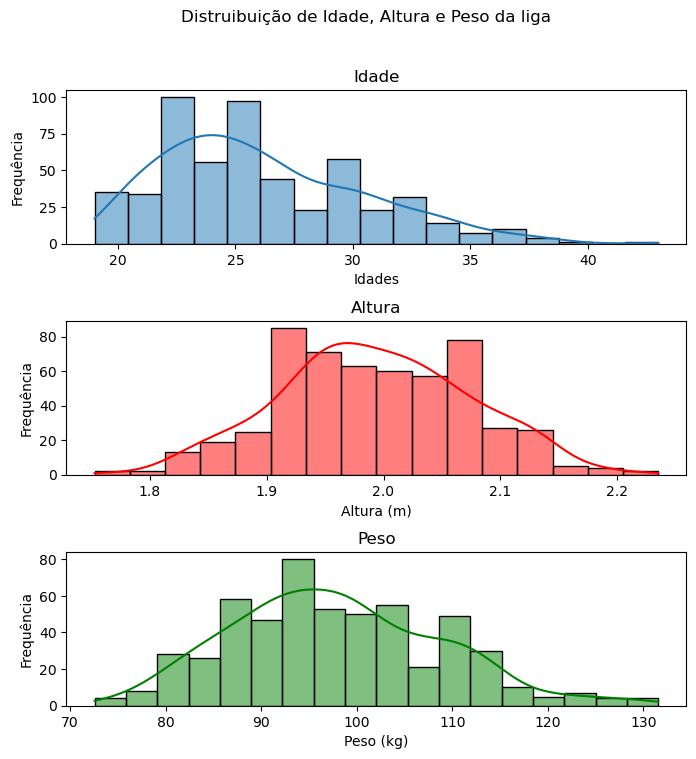

In [11]:
fig, ax = plt.subplots(nrows=3, figsize=(8,8))
plt.subplots_adjust(hspace=0.5)

sns.histplot(data=nba, x='age', ax=ax[0], kde=True)
ax[0].set_title('Idade')
ax[0].set_xlabel('Idades')
ax[0].set_ylabel('Frequência')

sns.histplot(data=nba, x='player_height', ax=ax[1], color='red', kde=True)
ax[1].set_title('Altura')
ax[1].set_xlabel('Altura (m)')
ax[1].set_ylabel('Frequência')

sns.histplot(data=nba, x='player_weight', ax=ax[2], color='green', kde=True)
ax[2].set_title('Peso')
ax[2].set_xlabel('Peso (kg)')
ax[2].set_ylabel('Frequência')

plt.suptitle('Distruibuição de Idade, Altura e Peso da liga')
plt.show()

### País de Origem

A NBA é considerada por muitas pessoas como a melhor liga de basquete do mundo, concentrando os melhores talentos do esporte na competição. A maioria dos jogadores são oriundos da América do Norte, sobre tudo Estados Unidos e - em menor escala - Canadá. Jogadores de diversas partes do mundo ingressam na NBA visando grandes salários e destaque midiático. 

Na temporada 2022-2023 tiveram jogadores de 44 países, sendo os principais: Estados Unidos, Canadá, Austrália, França, Alemanha, Nigéria, Sérvia, Espanha, Croácia e Turquia. Chama a atenção a quantidade de países europeus na listagem, porém, para quem conhece o "Eurobasket" não é uma surpresa a aparição de países do velho continente. Entretanto, é surpreendente a posição da Nigéria.

O Brasil teve apenas um jogador na NBA na temporada analisada. 

<center><img src="https://images2.minutemediacdn.com/image/upload/c_fill,w_720,ar_16:9,f_auto,q_auto,g_auto/shape/cover/sport/ae15f1a543d90eff3e19ff9cffe42851e035c850472e3d27b454d51aa1f875be.jpg" width="500"></center>
<center><font size="2">Raul Neto, o único brasileiro na temporada 22-23</font></center>

In [12]:
# Países com jogadores na NBA
nba['country'].unique()

array(['USA', 'Canada', 'Nigeria', 'Australia', 'Cameroon', 'Brazil',
       'Japan', 'France', 'Spain', 'Germany', 'Portugal', 'Jamaica',
       'Turkey', 'United Kingdom', 'Montenegro', 'Serbia', 'Georgia',
       'Slovenia', 'South Sudan', 'Czech Republic', 'Ukraine',
       'New Zealand', 'Italy', 'Democratic Republic of the Congo',
       'Greece', 'Lithuania', 'Israel', 'Croatia', 'Latvia', 'Bahamas',
       'Senegal', 'Argentina', 'DRC', 'Sudan', 'Dominican Republic',
       'Gabon', 'Switzerland', 'Saint Lucia', 'Angola',
       'Bosnia and Herzegovina', 'Guinea', 'Finland', 'Austria', 'Poland'],
      dtype=object)

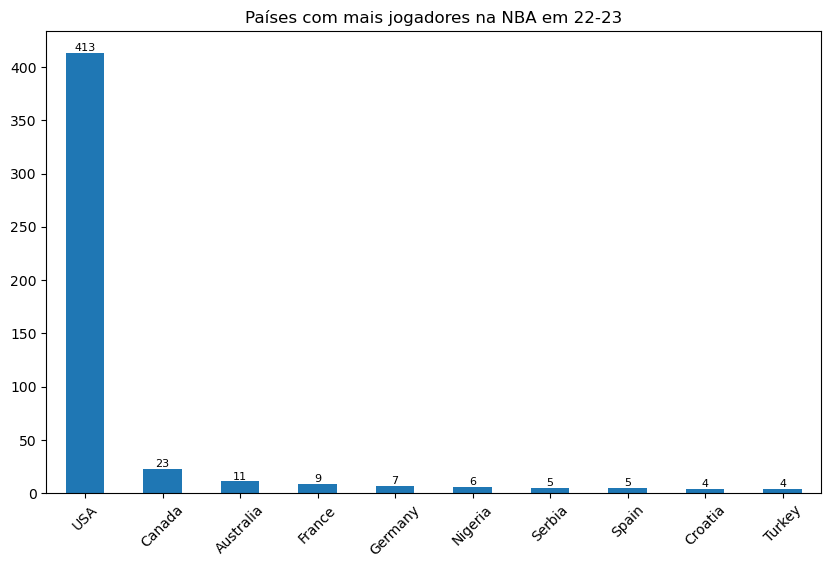

In [13]:
# Gráfico de barras dos países com mais jogadores na NBA
paises = nba['country'].value_counts().head(10)
fig = paises.plot(kind='bar', figsize=(10, 6))
fig.bar_label(fig.containers[0], fontsize=8)
plt.title('Países com mais jogadores na NBA em 22-23')
plt.xticks(rotation=45)
plt.xlabel('')
plt.show()

In [14]:
# Jogadores brasileiros
nba.query('country == "Brazil"')

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season,conference,nationality
15,Raul Neto,CLE,31.0,1.8796,81.64656,NaN,Brazil,2013,2,47,...,1.6,1.4,0.022,0.071,0.133,0.628,0.226,2022-23,East,Foreigner


### Draft da NBA e Faculdades

Na NBA a principal forma de ingresso na liga é através do Draft, um evento onde as equipes selecionam jogadores que se candidatam para participar. O Draft tem um limite mínimo e máximo de idade (19 a 22 anos), e na grande maioria, são jogadores que participam da _National Collegiate Athletic Association_ (NCAA), a liga universitária de basquete norte-americano. 

A faculdade em que o atleta estudou/jogou é um grande diferencial no Draft da NBA, haja vista que o retrospecto do jogador na liga universitária condiciona a sua posição de seleção no Draft. Jogadores que performam muito bem na NCAA têm grandes chances de serem escolhidos nas primeiras escolhas do Draft e isso influencia no salário e tempo de contrato do novato na liga.  

Porém, jovens jogadores que se destacam nas ligas profissionais de outros países também ganham oportunidade no Draft da NBA, e há também casos de jogadores que não entraram na liga via Draft, sendo esses jogadores com menos glamour e na maioria dos casos com tempo de contrato menor e poucos minutos de partida que os demais. 


<center><img src='https://library.sportingnews.com/styles/twitter_card_120x120/s3/2022-01/john-starks-ben-wallace-fred-vanvleet-best-undrafted-players-in-nba-historyjpeg_1vp12bqn10px713c1td3tkzn0k.jpeg?itok=4l5JusfK' width=500></center>
<center><font size='2'>Undrafteds que tiveram sucesso na NBA: John Starks, Ben Wallace, Fred VanVleet </font></center>

In [15]:
# Consultando a quantidade de atletas por rodada de draft
nba['draft_round'].value_counts()

draft_round
1            280
Undrafted    137
2            122
Name: count, dtype: int64

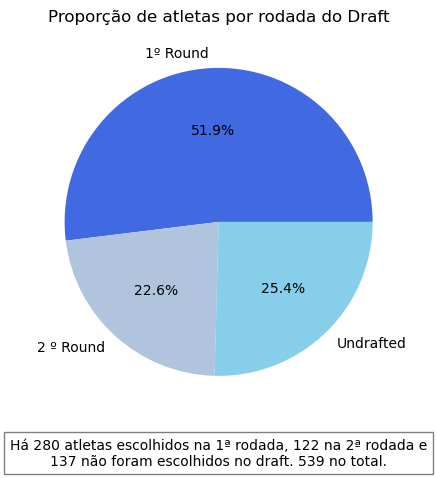

In [16]:
txt = 'Há 280 atletas escolhidos na 1ª rodada, 122 na 2ª rodada e\n137 não foram escolhidos no draft. 539 no total.'

plt.figure(figsize=(5,5))
draft = nba['draft_round'].value_counts().sort_index()
plt.pie(x = draft, labels=['1º Round', '2 º Round', 'Undrafted'], autopct='%1.1f%%', colors=['royalblue', 'lightsteelblue', 'skyblue'])
plt.title('Proporção de atletas por rodada do Draft')
plt.text(0, -1.5, txt, ha='center', va='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

### Estatísticas básicas de Jogo

Neste tópico iremos ver a distribuição das estatísticas como pontos, rebotes e assistencias por jogo, também iremos analisar os maiores pontuadores da temporada.

Em relação a pontuação a distribuição segue uma assimetria à direita (positiva) com uma quantidade considerável de *outliers*. A média da liga foi aproximadamente 9 pontos por jogo. Atletas com médias acima de 24 pts tiveram uma pontuação muito acima da grande maioria da NBA. O pivô camaronês do Philadelphia 76ers, Joel Embiid, foi o cestinha da temporada regular com 33.1 pontos por jogo. 

<img src='https://i.giphy.com/media/v1.Y2lkPTc5MGI3NjExenBmbTgxZHF4Z2w4a3U5NjlxYnh3YWJrcnpkeXlqbmxnNWN5ZThlNiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9cw/A4n7TmlEb9VH76MfYG/giphy.gif' width=150 align='right'>

In [17]:
# Consultando os limites inferior e superior dos pts 
pts_inf, pts_sup = limites_discrepantes(nba, 'pts')
pts_inf, pts_sup

(-7.774999999999999, 24.025)

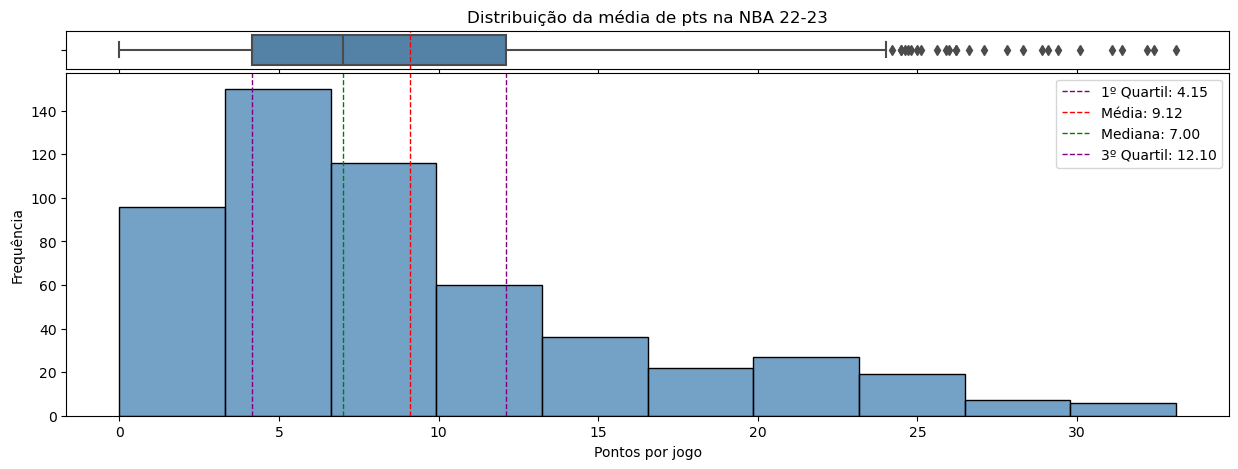

In [18]:
# Distribuição dos pontos na temporada.
histbox(nba, 'pts', size=(15,5), xlabel='Pontos por jogo', title='Distribuição da média de pts na NBA 22-23')

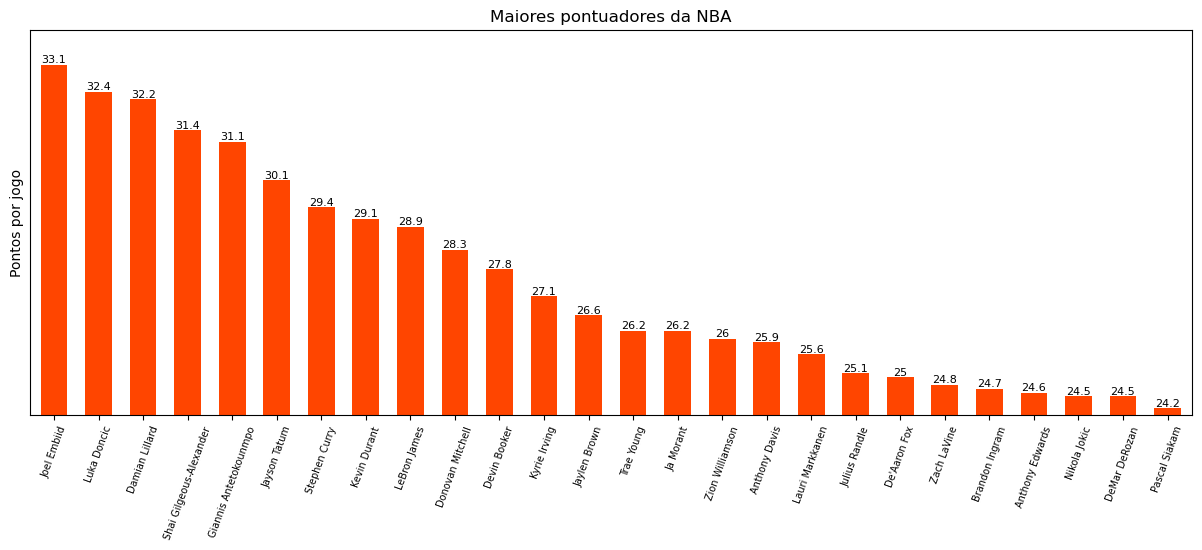

In [19]:
# Definindo a condição para selecionar os maiores pontuadores
condicao = nba['pts'] > pts_sup

# Obtendo os maiores pontuadores em ordem decrescente
cestinhas = nba.loc[condicao].sort_values('pts', ascending=False)

fig = cestinhas.plot.bar(x='player_name', y='pts', figsize=(15,5), title='Maiores pontuadores da NBA', color='orangered', legend=False, width=0.6)
fig.bar_label(fig.containers[0], fontsize=8)
plt.yticks([])
plt.xlabel('')
plt.ylabel('Pontos por jogo')
plt.ylim((pts_sup, 34))
plt.xticks(fontsize=7, rotation=70)
plt.show()

---
# Análise Bidimensional

Agora iremos analisar as relações entre algumas variáveis do conjunto de dados. 

- Conferência (Qualitativa) x Nativo ou Estrangeiro (Qualitativa)
- Altura (Quantitativa) x Eficiência de arremesso (Quantitativa)
- Draft Round (Qualitativa) x Média de pontos por jogo (Quantitativa)
  

### Qualitativa x Qualitativa 

Para a análise bidimensional entre duas variáveis qualitativas, iremos analisar a relação entre a quantidade de jogadores estrangeiros e as conferências (Oeste e Leste). O objetivo é investigar se os times de uma das duas conferências têm preferência para selecionar jogadores estrangeiros para seus elencos. 

Como vimos na parte de Importação e Seleção dos Dados, na variável _conference_ há 271 jogadores na Leste e 268 na Oeste. Já na variável _nationality_ temos 413 jogadores americanos e 126 estrangeiros, totalizando 539 atletas na temporada analisada.

In [21]:
# Tabela de contigência (Dupla Entrada)
pd.crosstab(nba['conference'], nba['nationality'], margins=True)

nationality,American,Foreigner,All
conference,,,
East,207,61,268
West,206,65,271
All,413,126,539


Para conferirmos se existe uma associação entre as variáveis, devemos obter a tabela de frequências esperadas e a medida de __Qui-Quadrado de Pearson__.

In [22]:
# Calculando o qui-quadrado e obtendo a tabela de frequências esperadas
chi2, pvalue, dof, freq_esperadas = stats.chi2_contingency(pd.crosstab(nba['conference'], nba['nationality']))

# Tabela de frequências esperadas 
pd.DataFrame(freq_esperadas, columns=['American','Foreigner'], index=['East','West'])

,American,Foreigner
East,205.350649,62.649351
West,207.649351,63.350649


In [23]:
print(f'O Qui-Quadrado é: {chi2}')

O Qui-Quadrado é: 0.05473267885663952


Comparando as frequências observadas com as frequências esperadas percebe-se que os valores são consideravelmente próximos. Quantificando essa associação, podemos calcular o __Coeficiente de Contigência__, definido por:


$$
C = \sqrt{\frac{\chi^2}{\chi^2 + n}}
$$

Onde:
- $\chi^2$ é o Qui-Quadrado de Pearson
- $n$ é o total geral de medições

In [24]:
from math import sqrt
c = sqrt(chi2/ (chi2 + nba.shape[0]))
print(f'O valor do coef. de contigência é: {c}')

O valor do coef. de contigência é: 0.010076435303260472


Como observado, a escolha de atletas por nacionalidade entre as confêrencias tem uma associação fraca, indicando que __não há indícios__ de que uma das duas conferências tem preferência para atletas estrangeiros.


---

### Quantitativa x Quantitativa 

Já se é sabido que jogadores mais altos dominam a disputa de rebotes no garrafão, porém há esteriótipo no imaginário coletivo de que jogadores altos não possuem um arremesso confiável, pontuando majoritariamente com bandejas e enterradas. Nesta análise, iremos analisar a associação entre a __altura dos jogadores__ e o seu __aproveitamento nos arremessos__.

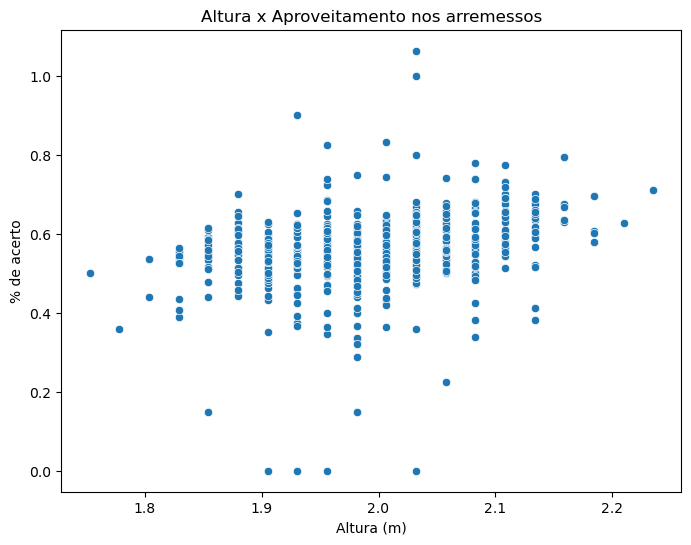

In [25]:
# Diagrama de Dispersão 
plt.figure(figsize=(8,6))
sns.scatterplot(data=nba, x='player_height', y='ts_pct')
plt.title('Altura x Aproveitamento nos arremessos')
plt.xlabel('Altura (m)')
plt.ylabel('% de acerto')
plt.show()

Observando o diagrama de dispersão, é possível notar que (surpreendentemente para alguns) parece haver uma associação linear positiva entre as variáveis. Dessa forma, iremos quantificar essa associação calculando a __covariância__ entre as variáveis e o seu __coeficiente de correlação de Pearson__.

O coeficiente de correlação de Pearson é definido como: 
$$
r = \frac{cov(X,Y)}{\sqrt{var(X) \cdot var(Y)}}
$$

Onde:
- $cov(X,Y)$ é a covariância entre duas variáveis
- $var(X)$ é a variância da primeia variável
- $var(Y)$ é a variância da segunda variável 


In [26]:
height = nba['player_height']
ts_pct = nba['ts_pct']

cov = np.cov(height, ts_pct)[0][1]

# Coeficiente de correlação de Pearson
corr, _ = stats.pearsonr(height, ts_pct)

print(f'A covariância entre idade e % Aproveitamento nos arremessos é: {cov}')
print(f'O coef. de Pearson é: {corr}')

A covariância entre idade e % Aproveitamento nos arremessos é: 0.0023628131415053357
O coef. de Pearson é: 0.2807492387164792


A covariância indica uma associação linear positiva porém muito baixa. Já a correlação indica que há uma associação abaixa, porém não desprezível.  

Realizando a regressão linear para encontrar a reta ótima, temos:

In [27]:
# Regressão Linear
beta, alpha, *_ = stats.linregress(height, ts_pct)

print(f'Coef. angular da reta ótima é: {beta} \nIntercepto: {alpha}')

Coef. angular da reta ótima é: 0.35416060859126774 
Intercepto: -0.14513414822032755


A reta obtida é:

$$
\hat y = -0.14513414822032755 + 0.35416060859126774x
$$

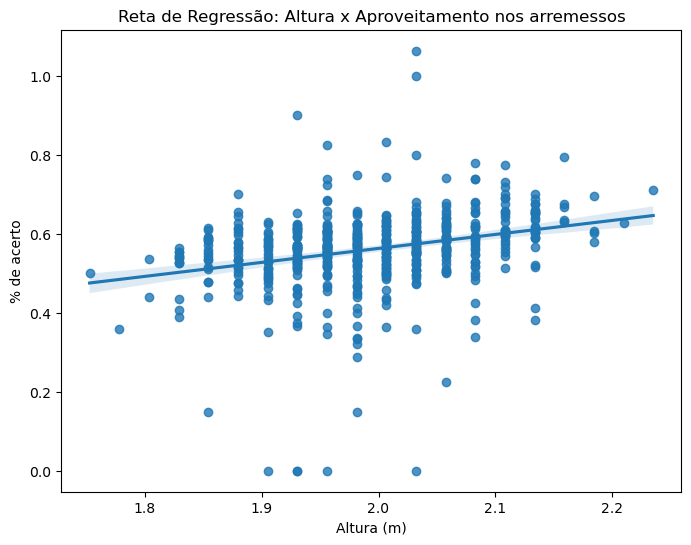

In [28]:
# Diagrama de Dispersão 
plt.figure(figsize=(8,6))
sns.regplot(data=nba, x='player_height', y='ts_pct')
plt.title('Reta de Regressão: Altura x Aproveitamento nos arremessos')
plt.xlabel('Altura (m)')
plt.ylabel('% de acerto')
plt.show()

Realizando uma previsão para um atleta de 2.05 metros de altura, temos:

In [35]:
aproveitamento = alpha + beta*2.05
aproveitamento

0.5808950993917713

Dessa forma, a crença de que atletas altos não têm arremessos consistentes se prova não ser fundada em dados, aos menos para esta temporada analisada. Essa relação entre altura e eficiência de arremessos talvez possa ser explicada pela dificuldade de bloquear arremessos de jogadores muito altos.

---

### Qualitativa x Quantitativa

Para a análise de correlação entre variáveis qualitativa e quantitativas, irei averiguar a associação entre __Draft Round__ (Rodada em que o jogador foi escolhido no Draft) e a __Média de pontos na temporada__. 

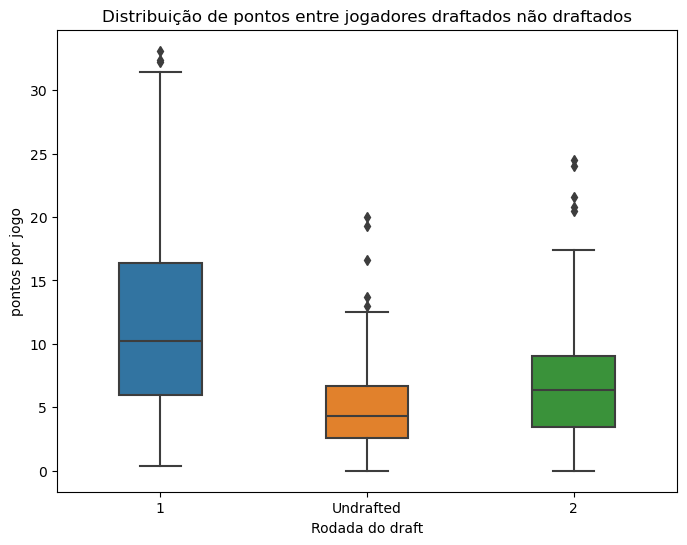

In [30]:
plt.figure(figsize=(8,6))
sns.boxplot(data=nba, y='pts', x='draft_round', width=0.4)
plt.title('Distribuição de pontos entre jogadores draftados não draftados')
plt.ylabel('pontos por jogo')
plt.xlabel('Rodada do draft')
plt.show()

O gráfico Box-Plot das categorias demonstram uma diferença na variabilidade entre a pontuação média de cada grupo. Uma forma de tentar explicar essa diferença é calcular o __coeficiente de determinação__


O coeficiente de determinação é definido como:

$$
R² = 1 - \frac{\bar s²}{s²}
$$

Onde: 
- $\bar s²$ é a média ponderada das variâncias de cada categoria
- $s²$ é a variância total da amostra 

In [31]:
# Pegando os valores por categoria
round1 = nba.query('draft_round == "1"')['pts']
round2 = nba.query('draft_round == "2"')['pts']
undrafteds = nba.query('draft_round == "Undrafted"')['pts']

# Obtendo as variâncias de cada amostra e a variância total
var_round1 = round1.var()
var_round2 = round2.var()
var_undrafteds = undrafteds.var()
var_total = nba['pts'].var()

# Calculando a média ponderada das variâncias
var_mean = (var_round1 * len(round1)) + (var_undrafteds * len(undrafteds)) + (var_round2 * len(round2)) 
var_mean = var_mean / nba.shape[0] 

print(f'A variância amostral dos jogadores draftados no 1 round: {var_round1:.3f}')
print(f'A variância amostral dos jogadores draftados no 2 round: {var_round2:.3f}')
print(f'A variância amostral dos jogadores não draftados: {var_undrafteds:.3f}')
print(f'A variância amostral total: {var_total:.3f}')

A variância amostral dos jogadores draftados no 1 round: 55.449
A variância amostral dos jogadores draftados no 2 round: 25.267
A variância amostral dos jogadores não draftados: 12.371
A variância amostral total: 46.816


In [32]:
# Calculando o coefieciente de determinação
r2 = 1 - (var_mean / var_total)
r2

0.19540253061933

O coeficiente determinação indica que 19.5% da variablidade total da média de pontos é explicada pela rodada de draft que o atleta foi selecionado.

# Conclusão 



Apesar da variáveis não apresentarem uma associação linear forte em nenhuma das análises bidimensionais realizadas, é possível constatar um certo grau de depedência em algumas avaliações. 

Para a análise entre variáveis qualitativa, os dados e testes mostram que não há uma preferência por parte dos times de uma das duas conferências para selecionar atletas estrangeiros, sendo a proporção de nativos e estrangeiros bem semelhante nas duas conferências.

Quanto a análise entre variáveis quantitativas, houve a "quebra" de um esteriótipo mostrando que jogadores altos tendem a ter um percentual de acerto grande. A correlação não é alta mas indica que há uma associação positiva entre altura e % de acerto nos arremessos. 

Por último, a análise entre variáveis quantitativas e qualitativas, que cerca de 20% da dispersão das médias de pontos entre os atletas da temporada 22-23 é explicada pela rodada em que o atleta foi selecionado no draft. De fato, jogadores escolhidos na primeira rodada acabam tendo médias maiores que os demais grupos. 